In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [37]:
df=pd.read_csv("Diabetes.csv")

In [38]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
94,2,142,82,18,64,24.7,0.761,21,0
95,6,144,72,27,228,33.9,0.255,40,0
96,2,92,62,28,0,31.6,0.130,24,0
97,1,71,48,18,76,20.4,0.323,22,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               99 non-null     int64  
 1   Glucose                   99 non-null     int64  
 2   BloodPressure             99 non-null     int64  
 3   SkinThickness             99 non-null     int64  
 4   Insulin                   99 non-null     int64  
 5   BMI                       99 non-null     float64
 6   DiabetesPedigreeFunction  99 non-null     float64
 7   Age                       99 non-null     int64  
 8   Outcome                   99 non-null     int64  
dtypes: float64(2), int64(7)
memory usage: 7.1 KB


In [40]:
df.shape

(99, 9)

In [41]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,4.646465,117.898990,67.848485,19.585859,72.878788,30.807071,0.470384,34.454545,0.363636
std,3.589421,33.881695,22.008979,16.082701,126.226980,9.472185,0.372773,11.264241,0.483494
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.102000,21.000000,0.000000
25%,1.500000,99.000000,64.000000,0.000000,0.000000,25.200000,0.248000,25.500000,0.000000
50%,4.000000,112.000000,72.000000,21.000000,0.000000,31.600000,0.344000,31.000000,0.000000
75%,7.000000,139.000000,80.000000,32.000000,110.000000,37.100000,0.584500,42.000000,1.000000
max,15.000000,197.000000,110.000000,60.000000,846.000000,48.800000,2.288000,60.000000,1.000000


In [42]:
from sklearn.model_selection import train_test_split
x=df.drop("Outcome",axis=1)
y=df["Outcome"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [43]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
49,7,105,0,0,0,0.0,0.305,24
70,2,100,66,20,90,32.9,0.867,28
68,1,95,66,13,38,19.6,0.334,25
15,7,100,0,0,0,30.0,0.484,32
39,4,111,72,47,207,37.1,1.390,56
...,...,...,...,...,...,...,...,...
60,2,84,0,0,0,0.0,0.304,21
71,5,139,64,35,140,28.6,0.411,26
14,5,166,72,19,175,25.8,0.587,51
92,7,81,78,40,48,46.7,0.261,42


In [44]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
62,5,44,62,0,0,25.0,0.587,36
40,3,180,64,25,70,34.0,0.271,26
95,6,144,72,27,228,33.9,0.255,40
18,1,103,30,38,83,43.3,0.183,33
97,1,71,48,18,76,20.4,0.323,22
84,5,137,108,0,0,48.8,0.227,37
64,7,114,66,0,0,32.8,0.258,42
42,7,106,92,18,0,22.7,0.235,48
10,4,110,92,0,0,37.6,0.191,30
0,6,148,72,35,0,33.6,0.627,50


In [45]:
y_train

49    0
70    1
68    0
15    1
39    1
     ..
60    0
71    0
14    1
92    0
51    0
Name: Outcome, Length: 79, dtype: int64

In [46]:
y_test

62    0
40    0
95    0
18    0
97    0
84    1
64    1
42    0
10    0
0     1
31    1
76    0
47    0
26    1
44    0
4     1
22    1
12    0
88    1
73    0
Name: Outcome, dtype: int64

In [47]:
df["Outcome"].value_counts(normalize=True)*100

Outcome
0    63.636364
1    36.363636
Name: proportion, dtype: float64

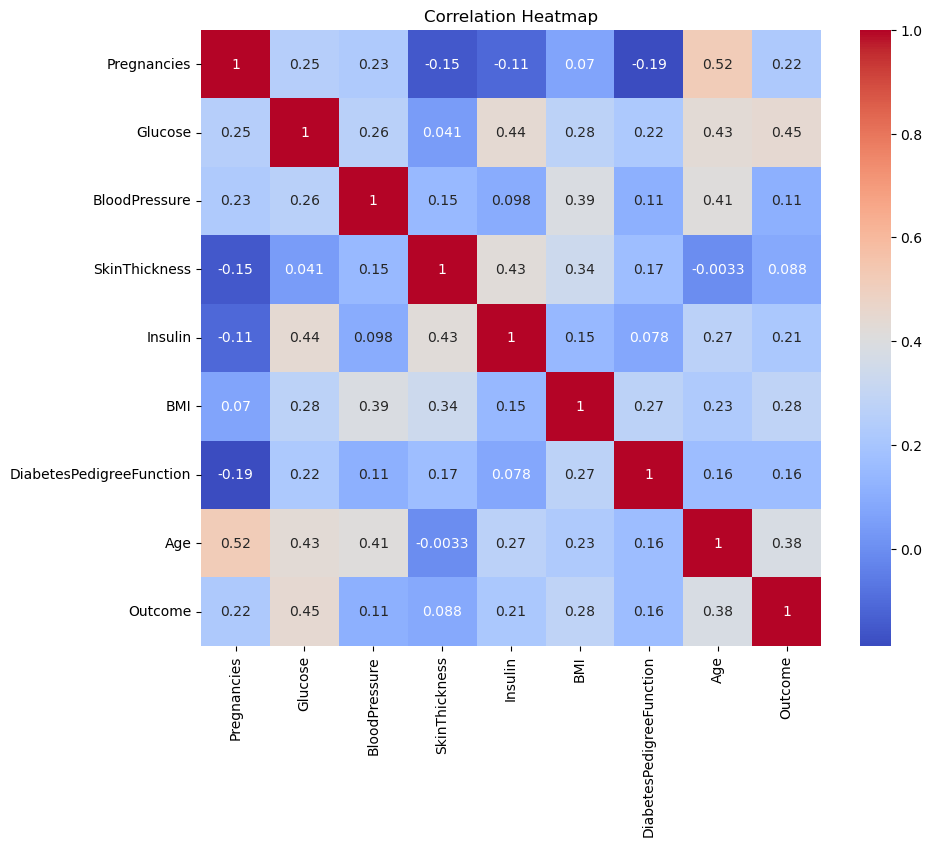

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [49]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

Accuracy: 0.65

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72        12
           1       0.57      0.50      0.53         8

    accuracy                           0.65        20
   macro avg       0.63      0.62      0.63        20
weighted avg       0.64      0.65      0.65        20



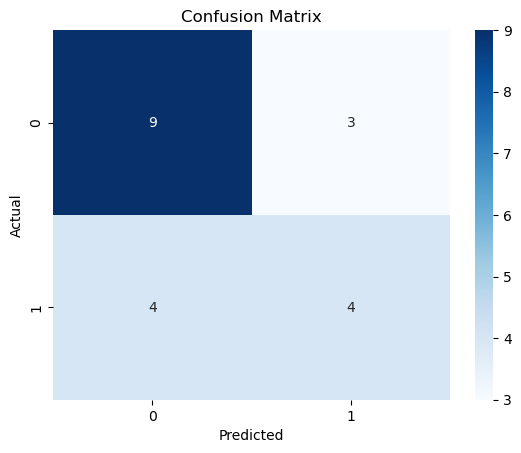

In [50]:
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [52]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(x_train_scaled, y_train)


LogisticRegression(class_weight='balanced', random_state=42)

In [53]:
y_pred = model.predict(x_test_scaled)


              precision    recall  f1-score   support

           0       1.00      0.58      0.74        12
           1       0.62      1.00      0.76         8

    accuracy                           0.75        20
   macro avg       0.81      0.79      0.75        20
weighted avg       0.85      0.75      0.75        20



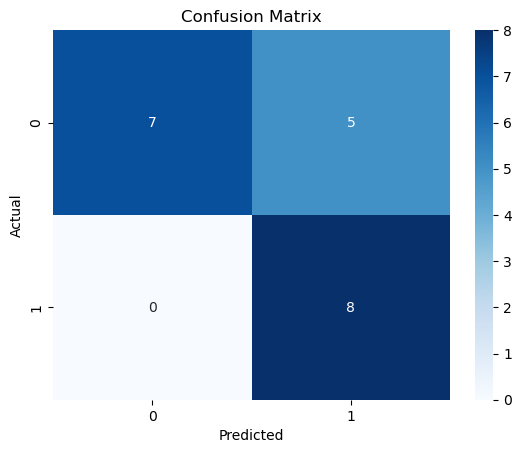

In [54]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

